In [1]:
import os
import cooltools
import cooler
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.ndimage as ndimage
import seaborn as sns
import pandas as pd
import subprocess
import bioframe
import gc
import warnings
from cytoolz import merge
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import matplotlib.pyplot as plt
from collections.abc import Iterable
from cooltools.api.saddle import saddle_strength

### Load Hi-C cool files (50kb resolution)

In [2]:
wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
old_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_old_50k.cool')
ko_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_KO_50k.cool')

con_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_control_50k.cool')
s1_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_step1_50k.cool')
s2_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_step2_50k.cool')

CLRS = [wt_clr, old_clr, ko_clr, con_clr, s1_clr, s2_clr]
LBLS = ['Adult', 'Old', 'S6-KO', 'Control', 'Step1', 'Step2']

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

### GC content calculation 

In [3]:
warnings.filterwarnings("ignore")

bins = wt_clr.bins()[:]
ref_genome = bioframe.load_fasta(ref_fasta)
gc_cov_wt = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

bins = ko_clr.bins()[:]
gc_cov_ko = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

bins = old_clr.bins()[:]
gc_cov_old = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

bins = con_clr.bins()[:]
gc_cov_con = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

bins = s1_clr.bins()[:]
gc_cov_s1 = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

bins = s2_clr.bins()[:]
gc_cov_s2 = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)

### Creating chromosome view dataframes

In [4]:
warnings.filterwarnings("ignore")

view_df_wt = pd.DataFrame({'chrom': wt_clr.chromnames,
                        'start': 0,
                        'end': wt_clr.chromsizes.values,
                          'name': wt_clr.chromnames}
                      )

view_df_ko = pd.DataFrame({'chrom': ko_clr.chromnames,
                        'start': 0,
                        'end': ko_clr.chromsizes.values,
                        'name': ko_clr.chromnames}
                      )


view_df_old = pd.DataFrame({'chrom': old_clr.chromnames,
                        'start': 0,
                        'end': old_clr.chromsizes.values,
                        'name': old_clr.chromnames}
                      )

view_df_con = pd.DataFrame({'chrom': con_clr.chromnames,
                        'start': 0,
                        'end': con_clr.chromsizes.values,
                        'name': con_clr.chromnames}
                      )

view_df_s1 = pd.DataFrame({'chrom': s1_clr.chromnames,
                        'start': 0,
                        'end': s1_clr.chromsizes.values,
                        'name': s1_clr.chromnames}
                      )

view_df_s2 = pd.DataFrame({'chrom': s2_clr.chromnames,
                        'start': 0,
                        'end': s2_clr.chromsizes.values,
                        'name': s2_clr.chromnames}
                      )

### Eigenvector calculation of chromatin interactions

In [5]:
warnings.filterwarnings("ignore")

cis_eigs_wt = cooltools.eigs_cis(
                        wt_clr,
                        gc_cov_wt,
                        view_df=view_df_wt,
                  
                        n_eigs=3,
                        )

eigenvector_track_wt = cis_eigs_wt[1][['chrom','start','end','E1']]

cis_eigs_ko = cooltools.eigs_cis(
                        ko_clr,
                        gc_cov_ko,
                        view_df=view_df_ko,
                    
                        n_eigs=3,
                        )

eigenvector_track_ko = cis_eigs_ko[1][['chrom','start','end','E1']]


cis_eigs_old = cooltools.eigs_cis(
                        old_clr,
                        gc_cov_old,
                        view_df=view_df_old,
                        
                        n_eigs=3,
                        )

eigenvector_track_old = cis_eigs_old[1][['chrom','start','end','E1']]

cis_eigs_con = cooltools.eigs_cis(
                        con_clr,
                        gc_cov_con,
                        view_df=view_df_con,
                        
                        n_eigs=3,
                        )

eigenvector_track_con = cis_eigs_con[1][['chrom','start','end','E1']]

cis_eigs_s1 = cooltools.eigs_cis(
                        s1_clr,
                        gc_cov_s1,
                        view_df=view_df_s1,
                        
                        n_eigs=3,
                        )

eigenvector_track_s1 = cis_eigs_s1[1][['chrom','start','end','E1']]

cis_eigs_s2 = cooltools.eigs_cis(
                        s2_clr,
                        gc_cov_s2,
                        view_df=view_df_s2,
                        
                        n_eigs=3,
                        )

eigenvector_track_s2 = cis_eigs_s2[1][['chrom','start','end','E1']]

### Expected contact matrix calculation

In [6]:
warnings.filterwarnings("ignore")

cvd_wt = cooltools.expected_cis(
        clr=wt_clr,
        view_df=view_df_wt
)

cvd_ko = cooltools.expected_cis(
        clr=ko_clr,
        view_df=view_df_ko
)


cvd_old = cooltools.expected_cis(
        clr=old_clr,
        view_df=view_df_old
)

cvd_con = cooltools.expected_cis(
        clr=con_clr,
        view_df=view_df_con
)

cvd_s1 = cooltools.expected_cis(
        clr=s1_clr,
        view_df=view_df_s1
)

cvd_s2 = cooltools.expected_cis(
        clr=s2_clr,
        view_df=view_df_s2
)

In [7]:
def saddle(
    clr,
    expected,
    track,
    contact_type,
    n_bins,
    vrange=None,
    qrange=None,
    view_df=None,
    clr_weight_name="weight",
    expected_value_col="balanced.avg",
    view_name_col="name",
    min_diag=3,
    max_diag=-1,
    trim_outliers=False,
    verbose=False,
    drop_track_na=False,
):
    """
    Get a matrix of average interactions between genomic bin
    pairs as a function of a specified genomic track.

    The provided genomic track is either:
    (a) digitized inside this function by passing 'n_bins', and one of 'v_range' or 'q_range'
    (b) passed as a pre-digitized track with a categorical value column as generated by `get_digitized()`.

    Parameters
    ----------
    clr : cooler.Cooler
        Observed matrix.
    expected : DataFrame in expected format
        Diagonal summary statistics for each chromosome, and name of the column
        with the values of expected to use.
    contact_type : str
        If 'cis' then only cis interactions are used to build the matrix.
        If 'trans', only trans interactions are used.
    track : DataFrame
        A track, i.e. BedGraph-like dataframe, which is digitized with
        the options n_bins, vrange and qrange. Can optionally be passed
        as a pre-digitized dataFrame with a categorical value column,
        as generated by get_digitzied(), also passing n_bins as None.
    n_bins : int or None
        number of bins for signal quantization. If None, then track must
        be passed as a pre-digitized track.
    vrange : tuple
        Low and high values used for binning track values.
        See get_digitized().
    qrange : tuple
        Low and high values for quantile binning track values.
        Low must be 0.0 or more, high must be 1.0 or less.
        Only one of vrange or qrange can be passed. See get_digitzed().
    view_df: viewframe
        Viewframe with genomic regions. If none, generate from track chromosomes.
    clr_weight_name : str
        Name of the column in the clr.bins to use as balancing weights.
        Using raw unbalanced data is not supported for saddles.
    expected_value_col : str
        Name of the column in expected used for normalizing.
    view_name_col : str
        Name of column in view_df with region names.
    min_diag : int
        Smallest diagonal to include in computation. Ignored with
        contact_type=trans.
    max_diag : int
        Biggest diagonal to include in computation. Ignored with
        contact_type=trans.
    trim_outliers : bool, optional
        Remove first and last row and column from the output matrix.
    verbose : bool, optional
        If True then reports progress.
    drop_track_na : bool, optional
        If True then drops NaNs in input track (as if they were missing),
        If False then counts NaNs as present in dataframe.
        In general, this only adds check form chromosomes that have all missing values, but does not affect the results.
    Returns
    -------
    interaction_sum : 2D array
        The matrix of summed interaction probability between two genomic bins
        given their values of the provided genomic track.
    interaction_count : 2D array
        The matrix of the number of genomic bin pairs that contributed to the
        corresponding pixel of ``interaction_sum``.
    """

    if type(n_bins) is int:
        # perform digitization
        track = align_track_with_cooler(
            track,
            clr,
            view_df=view_df,
            clr_weight_name=clr_weight_name,
            mask_clr_bad_bins=True,
            drop_track_na=drop_track_na,  # this adds check for chromosomes that have all missing values
        )
        digitized_track, binedges = digitize(
            track.iloc[:, :4],
            n_bins,
            vrange=vrange,
            qrange=qrange,
            digitized_suffix=".d",
        )
        digitized_col = digitized_track.columns[3]

    elif n_bins is None:
        # assume and test if track is pre-digitized
        digitized_track = track
        digitized_col = digitized_track.columns[3]
        is_track(track.astype({digitized_col: "float"}), raise_errors=True)
        if (
            type(digitized_track.dtypes[3])
            is not pd.core.dtypes.dtypes.CategoricalDtype
        ):
            raise ValueError(
                "when n_bins=None, saddle assumes the track has been "
                + "pre-digitized and the value column is a "
                + "pandas categorical. See get_digitized()."
            )
        cats = digitized_track[digitized_col].dtype.categories.values
        # cats has two additional categories, 0 and n_bins+1, for values
        # falling outside range, as well as -1 for NAs.
        n_bins = len(cats[cats > -1]) - 2
    else:
        raise ValueError("n_bins must be provided as int or None")

    if view_df is None:
        view_df = view_from_track(digitized_track)
    else:
        # Make sure view_df is a proper viewframe
        try:
            _ = is_compatible_viewframe(
                view_df,
                clr,
                check_sorting=True,  # just in case
                raise_errors=True,
            )
        except Exception as e:
            raise ValueError("view_df is not a valid viewframe or incompatible") from e

    # make sure provided expected is compatible
    try:
        _ = is_valid_expected(
            expected,
            contact_type,
            view_df,
            verify_cooler=clr,
            expected_value_cols=[
                expected_value_col,
            ],
            raise_errors=True,
        )
    except Exception as e:
        raise ValueError("provided expected is not compatible") from e

    # check if cooler is balanced
    if clr_weight_name:
        try:
            _ = is_cooler_balanced(clr, clr_weight_name, raise_errors=True)
        except Exception as e:
            raise ValueError(
                f"provided cooler is not balanced or {clr_weight_name} is missing"
            ) from e

    digitized_tracks = {}
    for num, reg in view_df.iterrows():
        digitized_reg = bioframe.select(digitized_track, reg)
        digitized_tracks[reg[view_name_col]] = digitized_reg[digitized_col]

    # set "cis" or "trans" for supports (regions to iterate over) and matrix fetcher
    if contact_type == "cis":
        # only symmetric intra-chromosomal regions :
        supports = list(zip(view_df[view_name_col], view_df[view_name_col]))

        getmatrix = _make_cis_obsexp_fetcher(
            clr,
            expected,
            view_df,
            view_name_col=view_name_col,
            expected_value_col=expected_value_col,
            clr_weight_name=clr_weight_name,
        )
    elif contact_type == "trans":
        # asymmetric inter-chromosomal regions :
        supports = list(combinations(view_df[view_name_col], 2))
        supports = [
            i
            for i in supports
            if (
                view_df["chrom"].loc[view_df[view_name_col] == i[0]].values
                != view_df["chrom"].loc[view_df[view_name_col] == i[1]].values
            )
        ]

        getmatrix = _make_trans_obsexp_fetcher(
            clr,
            expected,
            view_df,
            view_name_col=view_name_col,
            expected_value_col=expected_value_col,
            clr_weight_name=clr_weight_name,
        )
    else:
        raise ValueError("Allowed values for contact_type are 'cis' or 'trans'.")

    # n_bins here includes 2 open bins for values <lo and >hi.
    interaction_sum = np.zeros((n_bins + 2, n_bins + 2))
    interaction_count = np.zeros((n_bins + 2, n_bins + 2))

    for reg1, reg2 in supports:
        _accumulate(
            interaction_sum,
            interaction_count,
            getmatrix,
            digitized_tracks,
            reg1,
            reg2,
            min_diag=min_diag,
            max_diag=max_diag,
            verbose=verbose,
        )

    interaction_sum += interaction_sum.T
    interaction_count += interaction_count.T

    if trim_outliers:
        interaction_sum = interaction_sum[1:-1, 1:-1]
        interaction_count = interaction_count[1:-1, 1:-1]

    return interaction_sum, interaction_count

### Calculation of interaction sums and counts for saddle plots 

In [8]:
warnings.filterwarnings("ignore")

Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 38 


inter_sum_wt, inter_count_wt =  cooltools.saddle(
        wt_clr,
        cvd_wt,
        eigenvector_track_wt,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_wt
)

inter_sum_ko, inter_count_ko =  cooltools.saddle(
        ko_clr,
        cvd_ko,
        eigenvector_track_ko,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_ko
)


inter_sum_old, inter_count_old =  cooltools.saddle(
        old_clr,
        cvd_old,
        eigenvector_track_old,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_old
)

inter_sum_con, inter_count_con =  cooltools.saddle(
        con_clr,
        cvd_con,
        eigenvector_track_con,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_con
)

inter_sum_s1, inter_count_s1 =  cooltools.saddle(
        s1_clr,
        cvd_s1,
        eigenvector_track_s1,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_s1
)

inter_sum_s2, inter_count_s2 =  cooltools.saddle(
        s2_clr,
        cvd_s2,
        eigenvector_track_s2,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df_s2
)

In [9]:
from matplotlib.ticker import LogFormatter

class MinMaxFormatter(LogFormatter):
    def __init__(self, vmin, vmax, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.vmin = vmin
        self.vmax = vmax
    
    def __call__(self, x, pos=None):
        if x in [self.vmin, self.vmax]:
            return f"{x:g}"
        return ""

In [10]:
from cytoolz import merge

def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

#     warnings.warn(
#         "Generating a saddleplot will be deprecated in future versions, "
#         + "please see https://github.com/open2c_examples for examples on how to plot saddles.",
#         DeprecationWarning,
#     )

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
      
    else:
        print('cbar')

        #cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        #cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())
        cb = plt.colorbar(img, cax=grid["ax_cbar"], **cbar_kws)
        cb.set_ticks([vmin, vmax])
        cb.set_ticklabels([f"{vmin:g}", f"{vmax:g}"])
        cb.ax.yaxis.set_major_locator(plt.FixedLocator([vmin, vmax]))
        cb.ax.yaxis.set_minor_locator(plt.NullLocator())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)

    return grid

In [11]:
wt_saddle_matrix = inter_sum_wt/inter_count_wt
ko_saddle_matrix = inter_sum_ko/inter_count_ko
old_saddle_matrix = inter_sum_old/inter_count_old

con_saddle_matrix = inter_sum_con/inter_count_con
s1_saddle_matrix = inter_sum_s1/inter_count_s1
s2_saddle_matrix = inter_sum_s2/inter_count_s2

### Saddle plot ratio

In [12]:
## Old/Adult

cbar


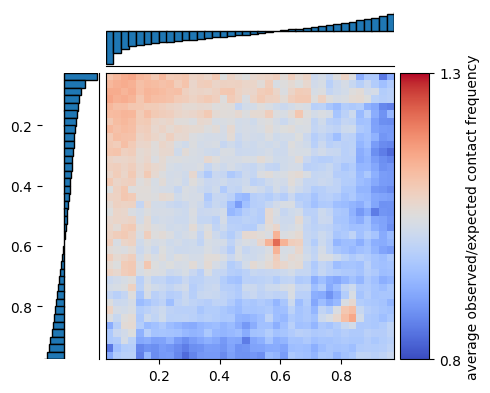

In [13]:
saddleplot(eigenvector_track_old,
           old_saddle_matrix/wt_saddle_matrix,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           vmin = 0.8,
           vmax = 1.3,
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [14]:
## S6-KO/Adult

cbar


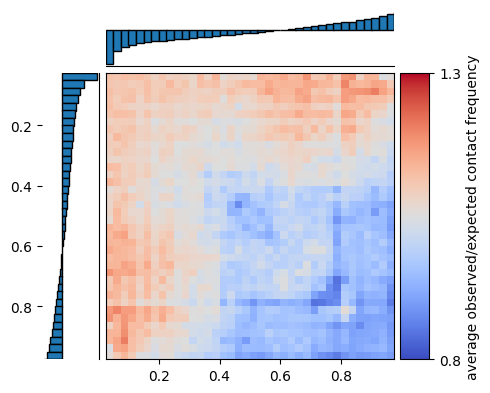

In [15]:
saddleplot(eigenvector_track_ko,
           ko_saddle_matrix/wt_saddle_matrix,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           vmin = 0.8,
           vmax = 1.3,
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [16]:
## Step1/Control

cbar


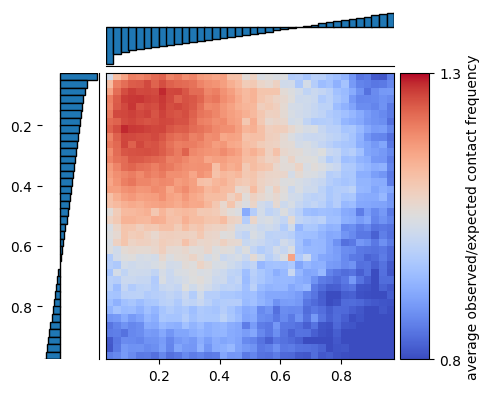

In [17]:
saddleplot(eigenvector_track_s1,
           s1_saddle_matrix/con_saddle_matrix,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           vmin = 0.8,
           vmax = 1.3,
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [18]:
## Step2/Control

cbar


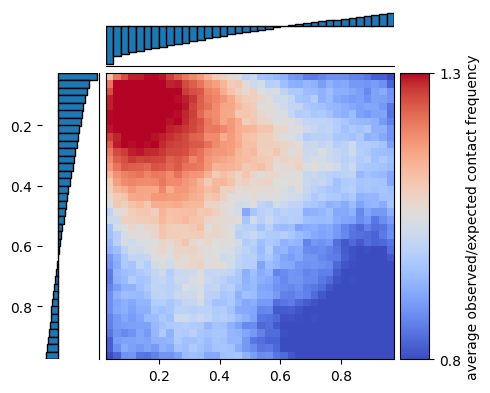

In [19]:
saddleplot(eigenvector_track_s2,
           s2_saddle_matrix/con_saddle_matrix,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           vmin = 0.8,
           vmax = 1.3,
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

### Compartment strength

In [20]:
def get_saddle_strength(saddle_matrix, formula='(AA + BB)/(AB + BA)'):
    num_rows = int(saddle_matrix.shape[0] * 0.1)
    num_cols = int(saddle_matrix.shape[1] * 0.1)
    BB = np.median(saddle_matrix[0:num_rows, 0:num_cols])
    AA = np.median(saddle_matrix[-num_rows: , -num_cols:])
    AB = np.median(saddle_matrix[0: num_rows, -num_cols:])
    BA = np.median(saddle_matrix[-num_rows: , 0:num_cols])
    return eval(formula)

In [21]:
adl = get_saddle_strength(wt_saddle_matrix)
old = get_saddle_strength(old_saddle_matrix)
ko = get_saddle_strength(ko_saddle_matrix)

con = get_saddle_strength(con_saddle_matrix)
s1 = get_saddle_strength(s1_saddle_matrix)
s2 = get_saddle_strength(s2_saddle_matrix)

print(f"Ratio of compartment strength for Old/Adult: {round(old / adl, 2)}")
print(f"Ratio of compartment strength for S6-KO/Adult: {round(ko / adl, 2)}")
print(f"Ratio of compartment strength for Step1/Control: {round(s1 / con, 2)}")
print(f"Ratio of compartment strength for Step2/Control: {round(s2 / con, 2)}")

Ratio of compartment strength for Old/Adult: 1.1
Ratio of compartment strength for S6-KO/Adult: 0.93
Ratio of compartment strength for Step1/Control: 1.13
Ratio of compartment strength for Step2/Control: 1.15


### Ratio of compartments' interaction intensity

In [22]:
def get_saddle_strength(saddle_matrix, formula='(AA + BB)/(AB + BA)'):
    num_rows = int(saddle_matrix.shape[0] * 0.1)
    num_cols = int(saddle_matrix.shape[1] * 0.1)
    BB = (saddle_matrix[0:num_rows, 0:num_cols])
    AA = (saddle_matrix[-num_rows: , -num_cols:])
    AB = (saddle_matrix[0: num_rows, -num_cols:])
    BA = (saddle_matrix[-num_rows: , 0:num_cols])
    return eval(formula)

In [23]:
import numpy as np
import pandas as pd

def calculate_ratios(condition_matrix, wt_matrix, condition_name):
    formulas = ['AA', 'BB', 'AB']
    ratios = []
    comps = []
    
    for formula in formulas:
        cond_val = get_saddle_strength(condition_matrix, formula=formula)
        wt_val = get_saddle_strength(wt_matrix, formula=formula)
        
        ratio_values = np.array(cond_val / wt_val).flatten()
        ratios.extend(ratio_values)
        comps.extend([formula] * len(ratio_values))
    
    return pd.DataFrame({
        'value': ratios,
        'comp': comps,
        'type': condition_name
    })

ko_wt_df = calculate_ratios(ko_saddle_matrix, wt_saddle_matrix, 'S6-KO/Adult')
old_wt_df = calculate_ratios(old_saddle_matrix, wt_saddle_matrix, 'Old/Adult')
s1_con_df = calculate_ratios(s1_saddle_matrix, con_saddle_matrix, 'Step1/Control')
s2_con_df = calculate_ratios(s2_saddle_matrix, con_saddle_matrix, 'Step2/Control')

In [24]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


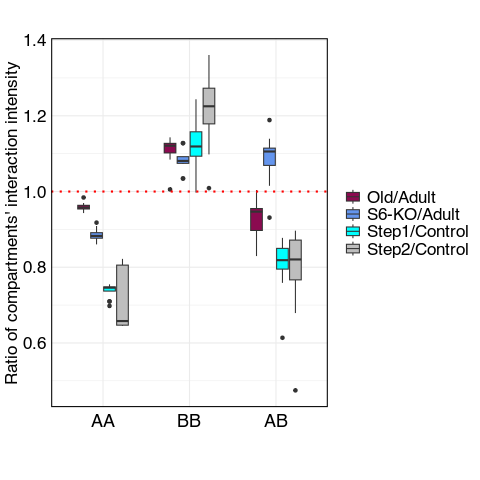

In [28]:
%%R

library(tidyverse)

ko_wt_df <- reticulate::py_eval('ko_wt_df')
old_wt_df <- reticulate::py_eval('old_wt_df')
s1_con_df <- reticulate::py_eval('s1_con_df')
s2_con_df <- reticulate::py_eval('s2_con_df')

df <- rbind(ko_wt_df, old_wt_df, s1_con_df, s2_con_df)
df$comp <- factor(df$comp, levels = c('AA', 'BB', 'AB'))
df$type <- factor(df$type, levels = c('Old/Adult', 'S6-KO/Adult', 'Step1/Control', 'Step2/Control'))

ggplot(df, aes(x = comp, y = value)) +
  geom_boxplot(aes(fill = type), width = 0.6) +
  xlab('') +
  ylab('Ratio of compartments\' interaction intensity') +
  #ylim(0.5, 1.5) +
  geom_hline(yintercept = 1, linetype = 'dotted', col = 'red', size = 1) + 
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 18, hjust = .5, vjust = .5, face = "plain"),
    axis.text.y = element_text(size = 17, colour = 'black'),
    axis.title.y = element_text(size = 17),
    legend.text = element_text(size = 17),
    legend.title = element_blank(),
    aspect.ratio = 4/3,
    panel.border = element_rect(colour = "black", fill = NA, size = 1)
  ) +
  scale_fill_manual(values = c('deeppink4', 'cornflowerblue', 'cyan', 'grey'))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure5_comp_ratio.pdf', dpi=1200)

# Differential compartments 

In [29]:
data_dir = '/tank/projects/kashuk_sirt6_hic/coolers/'
wt1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_2_50k.cool'))
wt2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_3_50k.cool'))
wt3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_m_1_50k.cool'))

old1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_2_50k.cool'))
old2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_3_50k.cool'))
old3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_m_1_50k.cool'))

ko1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_2_50k.cool'))
ko2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_3_50k.cool'))
ko3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_m_1_50k.cool'))

con1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_con_rep1_50k.cool'))
con2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_con_rep2_50k.cool'))
con3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_con_rep3_50k.cool'))

s1_1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step1_rep1_50k.cool'))
s1_2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step1_rep2_50k.cool'))
s1_3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step1_rep3_50k.cool'))

s2_1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step2_rep1_50k.cool'))
s2_2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step2_rep2_50k.cool'))
s2_3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_step2_rep3_50k.cool'))

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

### Calculate eigenvectors and eigenvalues 

In [30]:
def get_eigenvectors(clrs, ref_fasta='GRCm38.p6.genome.fa'):
    full_eigs = []
    eigenvectors = []
    if not isinstance(clrs, Iterable):
        clrs = tuple(clrs)
    for clr in clrs:
        bins = clr.bins()[:]
        ref_genome = bioframe.load_fasta(ref_fasta)
        gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)
        view_df = pd.DataFrame({'chrom': clr.chromnames,
                                'start': 0,
                                'end': clr.chromsizes.values,
                                'name': clr.chromnames}
                              )
        cis_eigs = cooltools.eigs_cis(clr, gc_cov, view_df=view_df, n_eigs=8, clr_weight_name='weight')
        full_eigs.append(cis_eigs)
        eigenvectors.append(cis_eigs[1][['chrom','start','end','E1','E2','E3','E4','E5','E6','E7','E8']])
    return full_eigs, eigenvectors

In [31]:
full_eigs, eigenvectors = get_eigenvectors((wt1, wt2, wt3, old1, old2, old3, ko1, ko2, ko3, con1, con2, con3, s1_1, s1_2, s1_3, s2_1, s2_2, s2_3), ref_fasta=ref_fasta)

In [32]:
wt1_eigs, wt2_eigs, wt3_eigs, old1_eigs, old2_eigs, old3_eigs, ko1_eigs, ko2_eigs, ko3_eigs, con1_eigs, con2_eigs, con3_eigs, stepone1_eigs, stepone2_eigs, stepone3_eigs, steptwo1_eigs, steptwo2_eigs, steptwo3_eigs = eigenvectors

In [33]:
%%R

library(reticulate)
library(limma)
library("ChIPpeakAnno")
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")
library(clusterProfiler)
library(biomaRt)
library(stringr)
library(tidyverse)
library("org.Mm.eg.db")

process_eigs_data <- function(tr_prefix, set_name) {
  # Load data
  wt1 <- py_eval('wt1_eigs')
  wt2 <- py_eval('wt2_eigs')
  wt3 <- py_eval('wt3_eigs')
  
  tr1 <- py_eval(paste0(tr_prefix, '1_eigs'))
  tr2 <- py_eval(paste0(tr_prefix, '2_eigs'))
  tr3 <- py_eval(paste0(tr_prefix, '3_eigs'))
  
  # Filter out chrX, Y, M
  filter_chrX <- function(df) df %>% filter(!grepl('chr[XMY]', chrom))
  wt1 <- filter_chrX(wt1)
  wt2 <- filter_chrX(wt2)
  wt3 <- filter_chrX(wt3)
  tr1 <- filter_chrX(tr1)
  tr2 <- filter_chrX(tr2)
  tr3 <- filter_chrX(tr3)
  
  # Create composite key
  wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")
  
  # # Fit linear model for each compartment bin
  m <- as.matrix(cbind(tr1[,4], tr2[,4], tr3[,4], wt1[,4], wt2[,4], wt3[,4]))
  rownames(m) <- wt1$comp
  m <- m[!rowSums(is.na(m)), ]
  
  d <- data.frame(condition = c(1, 1, 1, 0, 0, 0))
  fit <- lmFit(m, d)

  # Compute moderated t-statistics
  e <- eBayes(fit)
  
  df <- as.data.frame(m)
  df$p.value <- e$p.value[, "condition"]
  df$comp <- rownames(df)
  colnames(df)[1:6] <- c('tr1', 'tr2', 'tr3', 'wt1', 'wt2', 'wt3')
  
  # Filter significant changes by p.value < 0.05 and change between PC1 values by module > 0.3
  df_filt <- df[df$p.value < 0.05, ]
  df_filt$change1 <- abs(df_filt$tr1 - df_filt$wt1)
  df_filt$change2 <- abs(df_filt$tr2 - df_filt$wt2)
  df_filt$change3 <- abs(df_filt$tr3 - df_filt$wt3)
  df_filt$change <- rowMeans(df_filt[, 9:11], na.rm = TRUE)
  df_filt$wt <- rowMeans(df_filt[, 4:6], na.rm = TRUE)
  df_filt$tr <- rowMeans(df_filt[, 1:3], na.rm = TRUE)
  
  # Split genomic coordinates
  df_filt[c('chr', 'start', 'end')] <- str_split_fixed(df_filt$comp, "-", 3)
  final_df <- df_filt[df_filt$change > 0.3, ]
  
  # Annotate genomic regions
  gr <- GRanges(seqnames = final_df$chr,
                ranges = IRanges(start = as.numeric(final_df$start), 
                                end = as.numeric(final_df$end)))
  
  peakAnno <- annotatePeak(gr, 
                           TxDb = TxDb.Mmusculus.UCSC.mm10.ensGene, 
                           annoDb = "org.Mm.eg.db", 
                           addFlankGeneInfo = TRUE,  
                           flankDistance = 10000)
  ann <- as.data.frame(peakAnno)
  
  # Add annotation columns
  final_df$gene_id <- ann$geneId
  final_df$symbol <- ann$SYMBOL
  final_df$genename <- ann$GENENAME
  final_df$flank <- ann$flank_geneIds
  
  return(final_df)
}


final_df_old <- process_eigs_data("old", "Old")
final_df_ko <- process_eigs_data("ko", "S6-KO")

>> preparing features information...		 2025-08-04 05:10:32 PM 
>> identifying nearest features...		 2025-08-04 05:10:32 PM 
>> calculating distance from peak to TSS...	 2025-08-04 05:10:33 PM 
>> assigning genomic annotation...		 2025-08-04 05:10:33 PM 
>> adding gene annotation...			 2025-08-04 05:10:46 PM 
>> adding flank feature information from peaks...	 2025-08-04 05:10:46 PM 
>> assigning chromosome lengths			 2025-08-04 05:10:47 PM 
>> done...					 2025-08-04 05:10:47 PM 
>> preparing features information...		 2025-08-04 05:10:47 PM 
>> identifying nearest features...		 2025-08-04 05:10:47 PM 
>> calculating distance from peak to TSS...	 2025-08-04 05:10:47 PM 
>> assigning genomic annotation...		 2025-08-04 05:10:47 PM 
>> adding gene annotation...			 2025-08-04 05:10:49 PM 
>> adding flank feature information from peaks...	 2025-08-04 05:10:49 PM 
>> assigning chromosome lengths			 2025-08-04 05:10:49 PM 
>> done...					 2025-08-04 05:10:49 PM 


Loading required package: IRanges
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following object is masked from ‘package:limma’:

    plotMA

The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union

The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Ve

In [34]:
%%R

process_eigs_data <- function(tr_prefix, set_name) {
  # Load data
  wt1 <- py_eval('con1_eigs')
  wt2 <- py_eval('con2_eigs')
  wt3 <- py_eval('con3_eigs')
  
  tr1 <- py_eval(paste0(tr_prefix, '1_eigs'))
  tr2 <- py_eval(paste0(tr_prefix, '2_eigs'))
  tr3 <- py_eval(paste0(tr_prefix, '3_eigs'))
  
  # Filter out chrX, Y, M
  filter_chrX <- function(df) df %>% filter(!grepl('chr[XMY]', chrom))
  wt1 <- filter_chrX(wt1)
  wt2 <- filter_chrX(wt2)
  wt3 <- filter_chrX(wt3)
  tr1 <- filter_chrX(tr1)
  tr2 <- filter_chrX(tr2)
  tr3 <- filter_chrX(tr3)
  
  # Create composite key
  wt1$comp <- paste(wt1$chrom, wt1$start, wt1$end, sep = "-")
  
  # # Fit linear model for each compartment bin
  m <- as.matrix(cbind(tr1[,4], tr2[,4], tr3[,4], wt1[,4], wt2[,4], wt3[,4]))
  rownames(m) <- wt1$comp
  m <- m[!rowSums(is.na(m)), ]
  
  d <- data.frame(condition = c(1, 1, 1, 0, 0, 0))
  fit <- lmFit(m, d)

  # Compute moderated t-statistics
  e <- eBayes(fit)
  
  df <- as.data.frame(m)
  df$p.value <- e$p.value[, "condition"]
  df$comp <- rownames(df)
  colnames(df)[1:6] <- c('tr1', 'tr2', 'tr3', 'wt1', 'wt2', 'wt3')
  
  # Filter significant changes by p.value < 0.05 and change between PC1 values by module > 0.3
  df_filt <- df[df$p.value < 0.05, ]
  df_filt$change1 <- abs(df_filt$tr1 - df_filt$wt1)
  df_filt$change2 <- abs(df_filt$tr2 - df_filt$wt2)
  df_filt$change3 <- abs(df_filt$tr3 - df_filt$wt3)
  df_filt$change <- rowMeans(df_filt[, 9:11], na.rm = TRUE)
  df_filt$wt <- rowMeans(df_filt[, 4:6], na.rm = TRUE)
  df_filt$tr <- rowMeans(df_filt[, 1:3], na.rm = TRUE)
  
  # Split genomic coordinates
  df_filt[c('chr', 'start', 'end')] <- str_split_fixed(df_filt$comp, "-", 3)
  final_df <- df_filt[df_filt$change > 0.3, ]
  
  # Annotate genomic regions
  gr <- GRanges(seqnames = final_df$chr,
                ranges = IRanges(start = as.numeric(final_df$start), 
                                end = as.numeric(final_df$end)))
  
  peakAnno <- annotatePeak(gr, 
                           TxDb = TxDb.Mmusculus.UCSC.mm10.ensGene, 
                           annoDb = "org.Mm.eg.db", 
                           addFlankGeneInfo = TRUE,  
                           flankDistance = 10000)
  ann <- as.data.frame(peakAnno)
  
  # Add annotation columns
  final_df$gene_id <- ann$geneId
  final_df$symbol <- ann$SYMBOL
  final_df$genename <- ann$GENENAME
  final_df$flank <- ann$flank_geneIds
  
  return(final_df)
}


final_df_s1 <- process_eigs_data("stepone", "Step1")
final_df_s2 <- process_eigs_data("steptwo", "Step2")

>> preparing features information...		 2025-08-04 05:10:50 PM 
>> identifying nearest features...		 2025-08-04 05:10:50 PM 
>> calculating distance from peak to TSS...	 2025-08-04 05:10:50 PM 
>> assigning genomic annotation...		 2025-08-04 05:10:50 PM 
>> adding gene annotation...			 2025-08-04 05:10:52 PM 
>> adding flank feature information from peaks...	 2025-08-04 05:10:52 PM 
>> assigning chromosome lengths			 2025-08-04 05:10:53 PM 
>> done...					 2025-08-04 05:10:54 PM 
>> preparing features information...		 2025-08-04 05:10:54 PM 
>> identifying nearest features...		 2025-08-04 05:10:54 PM 
>> calculating distance from peak to TSS...	 2025-08-04 05:10:56 PM 
>> assigning genomic annotation...		 2025-08-04 05:10:56 PM 
>> adding gene annotation...			 2025-08-04 05:10:57 PM 
>> adding flank feature information from peaks...	 2025-08-04 05:10:57 PM 
>> assigning chromosome lengths			 2025-08-04 05:10:59 PM 
>> done...					 2025-08-04 05:10:59 PM 


'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns


In [35]:
## Prepare background as all genes in Adult compartment bins

wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
bins = wt_clr.bins()[:]

In [36]:
%%R

back = py_eval('bins')

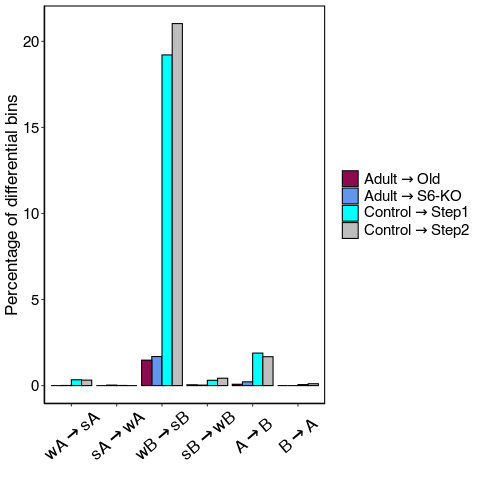

In [41]:
%%R

library(dplyr)

n_bins <- nrow(back)
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))

process_changes <- function(df, type_label, n_total) {
  counts <- c(
    `A->B` = sum(df$wt  >  0 & df$tr  <  0),
    `B->A` = sum(df$wt  <  0 & df$tr  >  0),
    `wB->sB` = sum(df$wt  > df$tr & df$wt  <  0 & df$tr <  0),
    `sB->wB` = sum(df$wt  < df$tr & df$wt  <  0 & df$tr <  0),
    `wA->sA`   = sum(df$wt  < df$tr & df$wt  >  0 & df$tr >  0),
    `sA->wA`   = sum(df$wt  > df$tr & df$wt  >  0 & df$tr >  0)
  )
  data.frame(
    change = names(counts),
    count  = round(counts / n_total * 100, 2),
    type   = type_label,
    stringsAsFactors = FALSE
  )
}

df_list <- list(
  `Adult->S6-KO`   = final_df_ko,
  `Adult->Old`     = final_df_old,
  `Control->Step1` = final_df_s1,
  `Control->Step2` = final_df_s2
)

df_all <- bind_rows(
  lapply(names(df_list), function(lbl) {
    process_changes(df_list[[lbl]], lbl, n_bins)
  })
)

df_all$change <- factor(df_all$change, levels = c(
  'wA->sA','sA->wA','wB->sB','sB->wB','A->B','B->A'
))
df_all$type <- factor(df_all$type, levels = c('Adult->Old', 'Adult->S6-KO', 'Control->Step1', 'Control->Step2'))

ggplot(data=df_all, aes(x=change, y=count, fill=type)) +
  geom_bar(stat="identity", color="black", position=position_dodge())+
  #ylim(0, 20) +
  ylab('Percentage of differential bins') + xlab('') +
  theme_classic() +
  scale_fill_manual(values=c('deeppink4','cornflowerblue','cyan', 'grey'),
                    labels=c(expression(Adult%->%Old), expression(Adult%->%'S6-KO'), expression(Control%->%Step1), expression(Control%->%Step2))) +
  theme(axis.title.y = element_text(size=17, colour='black'),
        axis.text.x = element_text(size=17, colour='black', angle = 40, vjust=0.5),
        axis.text.y = element_text(size=15, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        panel.border = element_rect(colour = "black", fill=NA, size=1)) +
  scale_x_discrete(labels = c(expression(wA%->%sA), expression(sA%->%wA), expression(wB%->%sB),
                              expression(sB%->%wB), expression(A%->%B), expression(B%->%A)))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure5_diff_comp_transitions.pdf')


In [44]:
%%R

df_all

#write.csv(df_all, '/tank/projects/kashuk_sirt6_hic/supplement/diff_compartments_transitions.csv')

            change count           type
A->B...1      A->B  0.22   Adult->S6-KO
B->A...2      B->A  0.00   Adult->S6-KO
wB->sB...3  wB->sB  1.69   Adult->S6-KO
sB->wB...4  sB->wB  0.03   Adult->S6-KO
wA->sA...5  wA->sA  0.01   Adult->S6-KO
sA->wA...6  sA->wA  0.03   Adult->S6-KO
A->B...7      A->B  0.08     Adult->Old
B->A...8      B->A  0.00     Adult->Old
wB->sB...9  wB->sB  1.48     Adult->Old
sB->wB...10 sB->wB  0.05     Adult->Old
wA->sA...11 wA->sA  0.00     Adult->Old
sA->wA...12 sA->wA  0.00     Adult->Old
A->B...13     A->B  1.89 Control->Step1
B->A...14     B->A  0.06 Control->Step1
wB->sB...15 wB->sB 19.21 Control->Step1
sB->wB...16 sB->wB  0.31 Control->Step1
wA->sA...17 wA->sA  0.34 Control->Step1
sA->wA...18 sA->wA  0.01 Control->Step1
A->B...19     A->B  1.68 Control->Step2
B->A...20     B->A  0.11 Control->Step2
wB->sB...21 wB->sB 21.03 Control->Step2
sB->wB...22 sB->wB  0.43 Control->Step2
wA->sA...23 wA->sA  0.32 Control->Step2
sA->wA...24 sA->wA  0.00 Control->Step2


In [45]:
%%R

back = py_eval('bins')

gr <- GRanges(seqnames=back[,1], ranges=IRanges(start=as.numeric(back[,2]), end=as.numeric(back[,3])))

txdb_mm10 <- TxDb.Mmusculus.UCSC.mm10.ensGene

peakAnno <- annotatePeak(gr, TxDb=TxDb.Mmusculus.UCSC.mm10.ensGene, annoDb = "org.Mm.eg.db", 
                         addFlankGeneInfo=TRUE,  flankDistance=10000)
ann <- as.data.frame(peakAnno)

back$gene_id <- ann$geneId
back$symbol <- ann$SYMBOL
back$genename <- ann$GENENAME
back$flank <- ann$flank_geneIds

# Compute background:
back <- back %>%
  filter(!grepl('chr[XMY]', chrom))
ids_back <- c(back$gene_id, 
              unlist(strsplit(na.omit(back$flank), ";")))
background <- unique(as.character(ids_back))

>> preparing features information...		 2025-08-04 05:17:32 PM 
>> identifying nearest features...		 2025-08-04 05:17:32 PM 
>> calculating distance from peak to TSS...	 2025-08-04 05:17:33 PM 
>> assigning genomic annotation...		 2025-08-04 05:17:33 PM 
>> adding gene annotation...			 2025-08-04 05:17:36 PM 
>> adding flank feature information from peaks...	 2025-08-04 05:17:36 PM 
>> assigning chromosome lengths			 2025-08-04 05:17:47 PM 
>> done...					 2025-08-04 05:17:47 PM 


'select()' returned 1:many mapping between keys and columns


In [53]:
%%R

perform_go_enrichment <- function(final_df, background, condition_name) {
  # Subset data for wB to sB compartment transition
  df_bB <- subset(final_df, wt > tr & wt < 0)
  
  # Extract gene IDs from flanking regions
  ids <- na.omit(df_bB$flank)
  ids <- unique(unlist(strsplit(ids, ";")))
  
  # Combine with main gene IDs
  ensembl <- unique(c(as.character(df_bB$gene_id), ids))
  
  # Run GO enrichment
  ego <- clusterProfiler::enrichGO(
    gene = ensembl,
    universe = background,
    keyType = 'ENSEMBL',
    OrgDb = org.Mm.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.1,
    minGSSize = 5,
    maxGSSize = 500
  )
  
  # Simplify GO terms
  ego2 <- clusterProfiler::simplify(
    ego,
    cutoff = 0.7,
    by = "p.adjust",
    select_fun = min,
    measure = "Wang"
  )
  
  d.ego <- data.frame(ego2)
  
  # Filter immune-related terms
  d.ego_immun <- d.ego %>% 
    filter(grepl('immun|B cell|defense', Description, ignore.case = TRUE))
  
  d.ego_immun <- d.ego_immun %>%
    mutate(GeneRatio = as.numeric(sub("/.*", "", GeneRatio)) / 
             as.numeric(sub(".*/", "", GeneRatio)))
  
  # Ighv gene analysis --------
  genes <- unique(unlist(strsplit(d.ego$geneID, "/")))
  
  mart <- biomaRt::useMart("ENSEMBL_MART_ENSEMBL", 
                          dataset = "mmusculus_gene_ensembl",
                          host = "https://www.ensembl.org")
  
  gene_info <- biomaRt::getBM(
    attributes = c("external_gene_name", "description", "ensembl_gene_id"), 
    filters = "ensembl_gene_id", 
    values = genes, 
    mart = mart
  )
  
  # Filter Ighv genes
  ighv <- gene_info %>% 
    filter(grepl('Ighv', external_gene_name))
  
  # Extract genomic bins associated with Ighv genes
  final_df_ighv <- data.frame()
  if(nrow(ighv) > 0) {
    for (id in ighv$ensembl_gene_id) {
      subset <- final_df[grepl(id, final_df$flank), ]
      if(nrow(subset) > 0) {
        final_df_ighv <- rbind(final_df_ighv, subset)
      }
    }
    
    if(nrow(final_df_ighv) > 0) {
      final_df_ighv <- final_df_ighv %>% 
        arrange(as.numeric(start)) %>%
        distinct(comp, .keep_all = TRUE)
    }
  }
  
  return(list(
    immun_go = d.ego_immun,
    ighv_bins = final_df_ighv
  ))
}

In [54]:
%%R

# Perform GO enrichment for all groups
results_old <- perform_go_enrichment(final_df_old, background, "Old")
results_ko <- perform_go_enrichment(final_df_ko, background, "S6-KO")
results_s1 <- perform_go_enrichment(final_df_s1, background, "Step1")
results_s2 <- perform_go_enrichment(final_df_s2, background, "Step2")

# Extract results
d.ego_immun_old <- results_old$immun_go
d.ego_immun_ko <- results_ko$immun_go
d.ego_immun_s1 <- results_s1$immun_go
d.ego_immun_s2 <- results_s2$immun_go

final_df_ighv_old <- results_old$ighv_bins
final_df_ighv_ko <- results_ko$ighv_bins
final_df_ighv_s1 <- results_s1$ighv_bins
final_df_ighv_s2 <- results_s2$ighv_bins

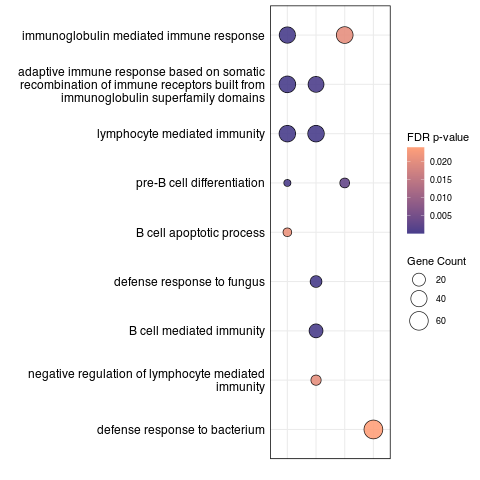

In [56]:
%%R
d.ego_immun_old$Group <- "Old"
d.ego_immun_ko$Group <- "S6-KO"
d.ego_immun_s1$Group <- "Step1"
d.ego_immun_s2$Group <- "Step2"

df_combined <- bind_rows(d.ego_immun_old, d.ego_immun_ko, d.ego_immun_s1, d.ego_immun_s2)

df_combined$Description <- str_wrap(df_combined$Description, width = 50) 

df_combined$Description <- factor(df_combined$Description, levels = rev(unique(df_combined$Description)))

ggplot(df_combined, aes(x = Group, y = Description, size = Count, fill = p.adjust)) +
  geom_point(alpha = 0.9, shape = 21, color = "black", stroke = 0.5) +  
  scale_size_continuous(range = c(3, 8.5)) +
  scale_fill_gradient(low = "darkslateblue", high = "lightsalmon1") +  
  labs(x = "", y = "", size = "Gene Count", fill = "FDR p-value") +  
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 12, color = 'black'),
    axis.text.x = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, size = 0.7)
  )

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/diff_comp_old_KO_step1_step2_GO.pdf', dpi=1200)

### Vienn diagram of Ighv genes intersection between groups

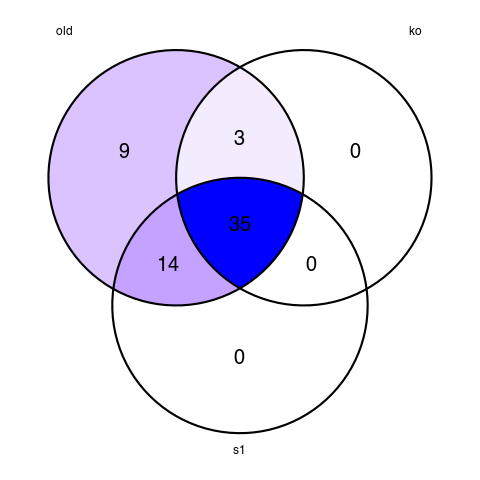

In [62]:
%%R

library(biomaRt)
library(ggVennDiagram)

dfs <- list(
  old = final_df_ighv_old,
  ko  = final_df_ighv_ko,
  s1  = final_df_ighv_s1
)

ensembl_lists <- lapply(dfs, function(df) {
  unique(unlist(strsplit(as.character(df$flank), ";")))
})

all_ids <- unique(unlist(ensembl_lists))

mart <- useMart("ENSEMBL_MART_ENSEMBL", 
                dataset = "mmusculus_gene_ensembl",
                host    = "https://www.ensembl.org")

gene_info <- getBM(
  attributes = c("ensembl_gene_id","external_gene_name","description"),
  filters    = "ensembl_gene_id",
  values     = all_ids,
  mart       = mart
)

gene_name_lists <- lapply(ensembl_lists, function(ids) {
  unique(gene_info$external_gene_name[
    gene_info$ensembl_gene_id %in% ids
  ])
})

ggVennDiagram(gene_name_lists, label = "count", label_alpha = 0, label_size =7) + 
  scale_fill_gradient(low = "white", high = "blue") + 
  theme(
    legend.position = "none", 
    text = element_text(size = 16), 
    strip.text = element_text(size = 25),  
    panel.grid = element_blank(),  
    plot.margin = margin(10, 10, 10, 10)
  ) +
  scale_x_continuous(expand = expansion(mult = 0.1))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Ighv_genes_Vienn_diagram.pdf', dpi=1200)